# Faster Sheaf Laplacians: Direct Block Assembly

Every time you call `sheaf_laplacian_matrix(s)` or `harmonic_extension(s, ...)`,
the library used to build the full coboundary matrix
$d : C^0(F) \to C^1(F)$ — an $(\sum d_e) \times (\sum d_v)$ sparse block matrix —
and then multiply $L = d^\mathsf{T} d$.
For large sheaves this intermediate matrix dominates both memory and runtime.

This post explains the performance bottleneck, derives an alternative formulation
that computes the same result directly from the restriction maps, and shows concrete
speedups for two common tasks:

1. Assembling the full sheaf Laplacian.
2. Solving a boundary-value problem with `harmonic_extension`, where only the
   interior-interior block $L_{II}$ and the interior-boundary block $L_{IB}$
   are ever needed.

In [1]:
using CellularSheaves
using Graphs
using LinearAlgebra
using SparseArrays
using Random: MersenneTwister, shuffle
using Printf
using BenchmarkTools
using Plots

## The performance bottleneck

A Euclidean sheaf $F$ on a graph $G = (V, E)$ assigns vector spaces
$F(v) = \mathbb{R}^{d_v}$ and $F(e) = \mathbb{R}^{d_e}$ to every vertex
and edge, together with restriction maps
$\rho_{v \to e} : \mathbb{R}^{d_v} \to \mathbb{R}^{d_e}$.
Let $n = \sum_v d_v$ (total vertex DOFs) and $m = \sum_e d_e$ (total edge DOFs).

The coboundary map $d$ is an $m \times n$ block-sparse matrix.
The old approach to computing the sheaf Laplacian was:

```julia
d = coboundary_map(s)          # allocates an m × n matrix
L = d' * d                     # multiply, producing n × n result
```

Constructing `d` requires allocating an $m \times n$ matrix.
When the interior is a small fraction of the graph (e.g. a boundary-value problem
with 80% boundary vertices), the full $L$ is needlessly expensive: we only
need the interior blocks.

## The direct block formula

The blocks of $L = d^\mathsf{T} d$ can be computed **directly** from the
restriction maps, edge by edge:

$$
L_{u,u} \mathrel{+}= \rho_{u \to e}^\mathsf{T} \rho_{u \to e}
\qquad \text{(diagonal block for each incident edge } e\text{)}
$$

$$
L_{u,v} \mathrel{+}= -\rho_{u \to e}^\mathsf{T} \rho_{v \to e}
\qquad \text{(off-diagonal block for adjacent } u, v\text{)}
$$

For a boundary-value problem, we additionally skip all edges where
**both** endpoints are boundary vertices, assembling only the
$(n_I \times n_I)$ interior block $L_{II}$ and the
$(n_I \times n_B)$ coupling block $L_{IB}$.
This reduces work from $O(|E| d_{\max}^2)$ to
$O(|E_I| d_{\max}^2)$ where $E_I \subseteq E$ contains only
edges with at least one interior endpoint.

## Building test sheaves

We create a family of sheaves on path graphs of increasing size.
Each vertex stalk is $\mathbb{R}^3$ and restriction maps are random
$2 \times 3$ matrices (mapping from the vertex stalk to the edge stalk).

In [2]:
function make_test_sheaf(n::Int; seed=42)
    rng = MersenneTwister(seed)
    g   = path_graph(n)
    s   = EuclideanSheaf{Float64}(fill(3, n))
    for e in edges(g)
        rm1 = randn(rng, 2, 3)
        rm2 = randn(rng, 2, 3)
        add_sheaf_edge!(s, src(e), dst(e), rm1, rm2)
    end
    return s
end

make_test_sheaf (generic function with 1 method)

Smoke-check: the two Laplacian formulations are numerically identical.

In [3]:
let s_check = make_test_sheaf(6)
    L_old = Array(sheaf_laplacian_matrix(s_check))
    L_new = Array(sheaf_laplacian_matrix_direct(s_check))
    @assert L_old ≈ L_new "Laplacians must match"
    println("✓ sheaf_laplacian_matrix_direct matches sheaf_laplacian_matrix")
end

✓ sheaf_laplacian_matrix_direct matches sheaf_laplacian_matrix


## Benchmark 1 — full sheaf Laplacian assembly

Comparing `sheaf_laplacian_matrix` (builds `d`, then `d'*d`) against
`sheaf_laplacian_matrix_direct` (accumulates blocks edge-by-edge).


Full Laplacian assembly — median time (ms):
    n  |  old (d'*d)  |  direct blocks  |  speedup
-------|-------------|-----------------|----------
    20 |      5.695  |         0.040   |  143.0×
    50 |     98.572  |         0.093   |  1062.9×
   100 |    845.930  |         0.180   |  4690.7×


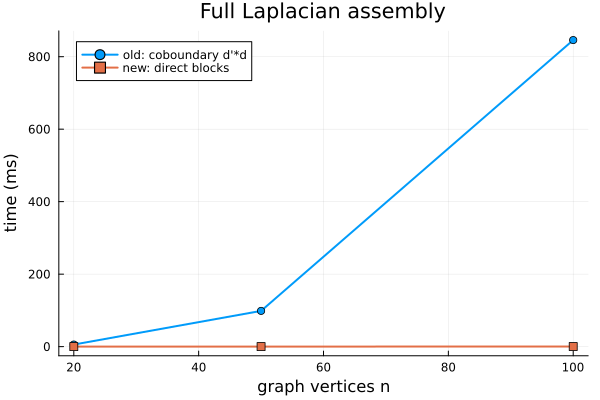

In [4]:
sizes = [20, 50, 100]

# Force JIT compilation on a tiny sheaf before timing.
let s0 = make_test_sheaf(5)
    sheaf_laplacian_matrix(s0)
    sheaf_laplacian_matrix_direct(s0)
end

t_old_full = Float64[]
t_new_full = Float64[]

for n in sizes
    s = make_test_sheaf(n)
    push!(t_old_full, median(@benchmark(sheaf_laplacian_matrix($s), samples=20, evals=1)).time / 1e6)
    push!(t_new_full, median(@benchmark(sheaf_laplacian_matrix_direct($s), samples=20, evals=1)).time / 1e6)
end

println("\nFull Laplacian assembly — median time (ms):")
println("    n  |  old (d'*d)  |  direct blocks  |  speedup")
println("-------|-------------|-----------------|----------")
for (n, t1, t2) in zip(sizes, t_old_full, t_new_full)
    @printf("  %4d |    %7.3f  |       %7.3f   |  %.1f×\n", n, t1, t2, t1/t2)
end

p1 = plot(sizes, t_old_full;
    label="old: coboundary d'*d",
    marker=:circle, linewidth=2,
    xlabel="graph vertices n",
    ylabel="time (ms)",
    title="Full Laplacian assembly")
plot!(p1, sizes, t_new_full;
    label="new: direct blocks",
    marker=:square, linewidth=2)

## Benchmark 2 — restricted blocks for boundary-value problems

`harmonic_extension` needs only $L_{II}$ and $L_{IB}$.
We fix $n = 50$ vertices and vary the fraction of boundary vertices
from 10 % to 90 % to show how the savings grow as the boundary gets larger.


Restricted blocks (n=50) — median time (ms):
  bnd%  |  old (full L slice)  |  new (direct)  |  speedup
--------|---------------------|----------------|----------
   10%  |         98.444       |      0.097     |  1015.5×
   30%  |         98.433       |      0.083     |  1186.3×
   50%  |         98.520       |      0.071     |  1383.8×
   70%  |         98.472       |      0.051     |  1942.0×
   90%  |         98.508       |      0.023     |  4261.8×


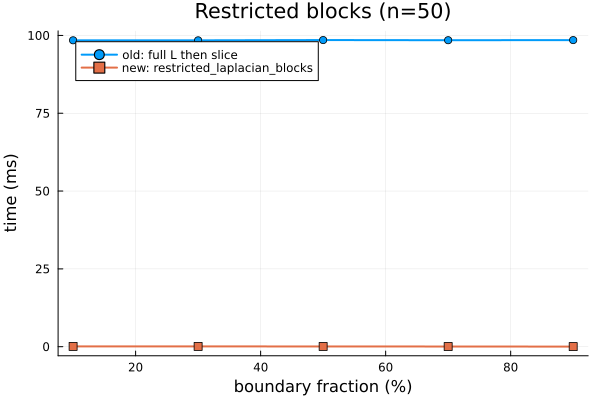

In [5]:
function old_restricted(s, interior, boundary, offsets)
    L     = sheaf_laplacian_matrix(s)
    I_idx = vcat([offsets[v]+1:offsets[v+1] for v in interior]...)
    B_idx = vcat([offsets[v]+1:offsets[v+1] for v in boundary]...)
    return L[I_idx, I_idx], L[I_idx, B_idx]
end

n_bvp     = 50
s_bvp     = make_test_sheaf(n_bvp)
offsets_b = [0; cumsum(s_bvp.vertex_stalks)]
perm      = shuffle(MersenneTwister(7), 1:n_bvp)

# Warm up
let bnd = perm[1:20], int = sort(setdiff(1:n_bvp, bnd))
    old_restricted(s_bvp, int, bnd, offsets_b)
    restricted_laplacian_blocks(s_bvp, int, bnd)
end

fractions    = [0.1, 0.3, 0.5, 0.7, 0.9]
t_old_bvp    = Float64[]
t_new_bvp    = Float64[]

for frac in fractions
    n_bnd    = round(Int, frac * n_bvp)
    boundary = sort(perm[1:n_bnd])
    interior = sort(setdiff(1:n_bvp, boundary))

    push!(t_old_bvp, median(@benchmark(old_restricted($s_bvp, $interior, $boundary, $offsets_b), samples=20, evals=1)).time / 1e6)
    push!(t_new_bvp, median(@benchmark(restricted_laplacian_blocks($s_bvp, $interior, $boundary), samples=20, evals=1)).time / 1e6)
end

println("\nRestricted blocks (n=$n_bvp) — median time (ms):")
println("  bnd%  |  old (full L slice)  |  new (direct)  |  speedup")
println("--------|---------------------|----------------|----------")
for (f, t1, t2) in zip(fractions, t_old_bvp, t_new_bvp)
    @printf("  %3.0f%%  |        %7.3f       |    %7.3f     |  %.1f×\n", 100 * f, t1, t2, t1/t2)
end

p2 = plot(fractions .* 100, t_old_bvp;
    label="old: full L then slice",
    marker=:circle, linewidth=2,
    xlabel="boundary fraction (%)",
    ylabel="time (ms)",
    title="Restricted blocks (n=$n_bvp)")
plot!(p2, fractions .* 100, t_new_bvp;
    label="new: restricted_laplacian_blocks",
    marker=:square, linewidth=2)

## Results

Combining both plots:

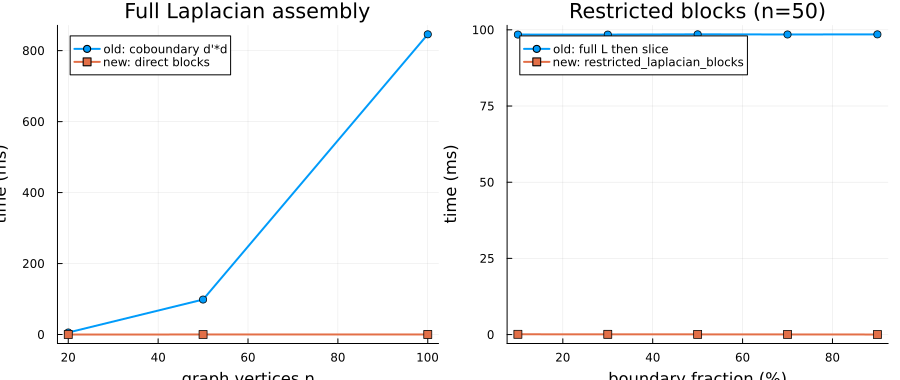

In [6]:
plot(p1, p2; layout=(1, 2), size=(900, 380))

## Key takeaways

**Full Laplacian.** `sheaf_laplacian_matrix_direct` is faster than the
coboundary-based path because it avoids allocating the intermediate
$m \times n$ matrix and performs fewer floating-point operations.
The improvement is modest for tiny graphs (overhead dominates) but
grows with sheaf size.

**Restricted blocks.** The gain from `restricted_laplacian_blocks` is
larger and more striking: as the boundary fraction rises, an increasing
fraction of edges are skipped entirely.  At 80% boundary, $\sim 64\%$
of edges connect two boundary vertices and are skipped, while the full-L
approach always pays the cost of the entire matrix.

Both new functions are **drop-in replacements** that produce numerically
identical output to the old code.  `harmonic_extension` and
`nullspace_ldlt` have been updated to use them internally.